#### Imports

In [12]:
import importlib
import matplotlib.pyplot as plt
import numpy as np
import copy
import random
import os
from pathlib import Path
import pandas as pd
import time
import itertools
import re
import warnings

from tqdm import tqdm
from collections import defaultdict
import torch
from torchinfo import summary as info_summary
from torchsummary import summary as sum_summary
import pickle

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

import globals
import utils
import nn_dataset
import nn_models

np.set_printoptions(precision=4, suppress=True, linewidth=np.inf, threshold=np.inf)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Current device:", device)

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

Current device: cuda


In [13]:
importlib.reload(globals)
importlib.reload(utils)
importlib.reload(nn_dataset)
importlib.reload(nn_models)

<module 'nn_models' from 'c:\\Users\\Matteo\\Desktop\\Scuola\\MastersThesis\\Masters_Thesis\\nn_models.py'>

In [14]:
param_names, function_names = utils.inspect_metadata(globals.CURRENT_TRAIN_FILE)

Keys in train_file: ['I0', 'LUTdata', 'LUTheader', 'dynamic', 'static', 'wvl']

Attributes in LUTheader (inputs):
  varnames: O3STR,H2OSTR,VIS,G,ASTMX,SSA,PARM2,OBSZEN,PARM1

Attributes in train_file (outputs):
  RTMname: MODTRAN6
  inputmode: Latin hypercube
  lut_package_date: 10-Apr-2025
  opmode: Transfer Functions
  outnames: Lp0,Edir0,Edif0,S,tdir,tdif
  sensor: Empty(dtype=dtype('O'))

LUTheader shape: (500, 9)
LUTdata shape: (500, 25230)
wvl shape: (1, 4205)


In [15]:
X, Y, wavelengths = utils.load_train_h5(globals.CURRENT_TRAIN_FILE)
wavelengths = wavelengths.squeeze()
Y_resh = Y.reshape(-1, Y.shape[1] // len(wavelengths), len(wavelengths))

#### Features Definition and Selection

In [ ]:
def build_physics_features(X, eps=1e-8):
    """
    Expand RT atmospheric inputs with physics-informed features.

    Input columns:
        0: O3
        1: CWV
        2: AOD
        3: Asy. Param. (g)
        4: Ang. Exp. (AE)
        5: SSA
        6: SZA
        7: VZA
        8: RAA

    Returns:
        X_expanded, feature_names
    """

    # unpack
    O3  = X[:, 0]
    CWV = X[:, 1]
    AOD = X[:, 2]
    g   = X[:, 3]
    AE  = X[:, 4]
    SSA = X[:, 5]
    SZA = X[:, 6]
    VZA = X[:, 7]
    RAA = X[:, 8]

    # radians
    sza = np.deg2rad(SZA)
    vza = np.deg2rad(VZA)
    raa = np.deg2rad(RAA)

    # geometric path length
    mu_s = np.cos(sza)
    mu_v = np.cos(vza)
    sec_sza = 1.0 / (mu_s + eps)
    sec_vza = 1.0 / (mu_v + eps)
    airmass = sec_sza + sec_vza


    # gas absorption path features
    CWV_airmass = CWV * airmass
    log_CWV = np.log(CWV + eps)
    O3_airmass = O3 * airmass
    log_O3 = np.log(O3 + eps)
    CWV_sec_sza = CWV * sec_sza


    # aerosol optical features
    log_AOD = np.log(AOD + eps)
    AOD_sec_sza = AOD * sec_sza
    AOD_airmass = AOD * airmass
    AE_squared = AE**2
    AOD_AE = AOD * AE


    # aerosol absorption/scattering
    absorption_fraction = 1 - SSA
    aerosol_absorption_OD = (1 - SSA) * AOD
    aerosol_scattering_OD = SSA * AOD
    g_squared = g**2
    SSA_g = SSA * g
    g_AOD = g * AOD


    # backscatter fraction
    Ba_g = (
        (1 - g) / (2 * g + eps)
        *
        (
            (1 + g) / np.sqrt(1 + g**2 + eps)
            - 1
        )
    )


    # scattering geometry
    cos_theta = (
        -np.cos(sza) * np.cos(vza)
        + np.cos(raa) * np.sin(sza) * np.sin(vza)
    )
    mu = np.cos(np.deg2rad(SZA)) * np.cos(np.deg2rad(VZA))


    # assemble
    features = [
        # original variables
        O3,
        CWV,
        AOD,
        g,
        AE,
        SSA,
        SZA,
        VZA,
        RAA,

        # geometry
        mu_s,
        sec_sza,
        mu_v,
        sec_vza,
        airmass,

        # gases
        CWV_airmass,
        log_CWV,
        O3_airmass,
        log_O3,
        CWV_sec_sza,

        # aerosols
        log_AOD,
        AOD_sec_sza,
        AOD_airmass,
        AE_squared,
        AOD_AE,

        # scattering properties
        absorption_fraction,
        aerosol_absorption_OD,
        aerosol_scattering_OD,
        g_squared,
        SSA_g,
        g_AOD,
        Ba_g,

        # phase geometry
        cos_theta,
        mu,
    ]


    feature_names = [
        "O3",
        "CWV",
        "AOD",
        "g",
        "AE",
        "SSA",
        "SZA",
        "VZA",
        "RAA",

        "cos_SZA",
        "sec_SZA",
        "cos_VZA",
        "sec_VZA",
        "airmass",

        "CWV_airmass",
        "log_CWV",
        "O3_airmass",
        "log_O3",
        "CWV_sec_SZA",

        "log_AOD",
        "AOD_sec_SZA",
        "AOD_airmass",
        "AE_squared",
        "AOD_AE",

        "1_minus_SSA",
        "AOD_absorption_OD",
        "AOD_scattering_OD",
        "g_squared",
        "SSA_g",
        "g_AOD",
        "Ba_g",

        "cos_scattering_angle",
        "mu",
    ]


    X_expanded = np.column_stack(features)
    return X_expanded, feature_names

X_expanded, feature_names = build_physics_features(X)
print(f"X expanded shape: {X_expanded.shape}\n")

X_tr, X_val, X_test, Y_tr, Y_val, Y_test = utils.train_val_test_split(X, Y_resh, wavelengths, verbose=True)
print()
X_tr_expanded, X_val_expanded, X_test_expanded, Y_tr, Y_val, Y_test = utils.train_val_test_split(X_expanded, Y_resh, wavelengths, verbose=True)

X expanded shape: (500, 33)

X shape: (500, 9)
Y shape: (500, 6, 4205)
wavelengths shape: (4205,)

X_tr shape: (400, 9)
X_val shape: (50, 9)
X_test shape: (50, 9)

Y_tr shape: (400, 6, 4205)
Y_val shape: (50, 6, 4205)
Y_test shape: (50, 6, 4205)

X shape: (500, 33)
Y shape: (500, 6, 4205)
wavelengths shape: (4205,)

X_tr shape: (400, 33)
X_val shape: (50, 33)
X_test shape: (50, 33)

Y_tr shape: (400, 6, 4205)
Y_val shape: (50, 6, 4205)
Y_test shape: (50, 6, 4205)


The code below is a Python port of a MATLAB feature-selection / SIC-method code.

Original MATLAB methods by the author Dr. Luca Martino (Universidad Rey Juan Carlos):
<ul>
    <li>Feature Selection: greedy forward feature ranking based on a 2nd degree polynomial-fit emulator's prediction error.</li>
    <li>SIC Method: Spectral Information Criterion (elbow method) used to automatically decide how many of the ranked features to keep.</li>
</ul>

Indexing note: everything below has been converted from MATLAB's 1-based indexing to Python's 0-based indexing. Selected feature indices returned by `feature_selection` are therefore 0-based column indices into `Xt`.

Error at SIC selection: 0.8770525254025678


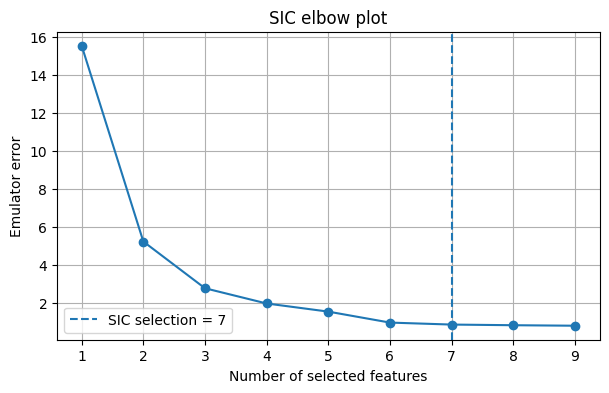

Selected (0-based) feature indices: [0 1 2 3 4 5 6]
Sensitivities: [0.0005 0.0035 0.936  0.0025 0.0107 0.0019 0.0447]


In [ ]:
class FeatureSelectionEmulator:
    """
    Minimal container mirroring the MATLAB `obj` that featureSelection and
    SICmethod were methods of (obj.conf.kernel, obj.SICmethod(...)).
    """

    def __init__(self, kernel='none', interp_func=None):
        """
        kernel : str
            Equivalent to `obj.conf.kernel`. If this equals 'mahalanobissquaredexponential', the SIC elbow-detection step
            is skipped and *all* ranked features are kept (matching the MATLAB `if ~strcmp(...)` branch).
        interp_func : callable
            The emulator/interpolation function.
        """
        self.conf = {'kernel': kernel}
        self.interp_func = interp_func

    # ------------------------------------------------------------------
    def feature_selection(self, Xt, Yt, alpha=1.0, plotting=False):
        """
        Ranks the input variables by importance based on the accuracy of
        a polynomial fitting, recursively adding more input variables.
        Once ranked, the Spectral Information Criterion (SIC) method is
        applied to automatically select the minimum number of features.

        Xt : ndarray, shape (n_samples, n_features)
            Training inputs (each column is a candidate feature).
        Yt : ndarray, shape (n_samples, n_outputs)
            Training targets (e.g. samples of a transfer function).
        alpha : float, optional
            Exponent used in the error metric |Yt - out|**alpha.
            Default 1 (L1 norm), matching the MATLAB code.

        Returns
        -------
        features : ndarray of int
            0-based indices of the selected features, sorted ascending.
        w : ndarray of float
            Normalized sensitivity ("importance") of each selected feature, in the same order as `features`.
        """
        warnings.filterwarnings('ignore')

        Xt = np.asarray(Xt)
        Yt = np.asarray(Yt, dtype=float)
        if Yt.ndim == 1:
            Yt = Yt.reshape(-1, 1)

        n_samples, n_features = Xt.shape

        ii = list(range(n_features))        # remaining candidate features
        features = []                       # ranked feature indices (growing list)
        feat_err = np.full(n_features, np.nan)

        k = 0
        while len(ii) > 0:
            err = np.full(len(ii), np.nan)

            for i, cand in enumerate(ii):
                cols = features + [cand]
                X = Xt[:, cols].T  # shape (n_selected+1, n_samples), like MATLAB's X'

                out = self.interp_func(X, Yt, X, 'polyfit')
                out = np.asarray(out, dtype=float)

                aux = np.abs(Yt - out) ** alpha
                aux = np.mean(aux, axis=1)          # average across outputs (columns)
                aux[np.isinf(aux)] = 0

                if aux.size > 1:
                    valid = aux[aux < (1e4 ** alpha)]
                    err[i] = np.nanmean(valid) if valid.size else np.nan
                else:
                    err[i] = aux.item()

            j = int(np.nanargmin(err))
            feat_err[k] = err[j]
            features.append(ii[j])
            del ii[j]
            k += 1

        # --- select number of features via the SIC elbow method ---------
        if self.conf.get('kernel') != 'mahalanobissquaredexponential':
            idfeat = self.sic_method(feat_err, 99)
            if plotting:
                self.plot_elbow(feat_err, idfeat)
        else:
            idfeat = len(features)

        # --- "no features" baseline: error vs. the average spectrum ------
        baseline = np.abs(Yt - np.mean(Yt, axis=1, keepdims=True)) ** alpha
        baseline[np.isinf(baseline)] = np.nan
        baseline = np.nanmean(baseline, axis=1)
        baseline[np.isinf(baseline)] = 0
        if baseline.size > 1:
            valid = baseline[baseline < (1e4 ** alpha)]
            baseline_err = np.nanmean(valid) if valid.size else np.nan
        else:
            baseline_err = baseline.item()

        feat_err_full = np.concatenate(([baseline_err], feat_err))

        # --- sensitivity: normalized drop in error when adding a feature -
        w_full = np.abs(np.diff(feat_err_full))
        w_full = w_full / np.sum(w_full)
        w_full = np.nan_to_num(w_full)

        # --- keep the first `idfeat` (already ranked) features, sort them
        features = np.array(features)
        selected = features[:idfeat]
        order = np.argsort(selected)
        features_sorted = selected[order]
        w = w_full[:idfeat][order]

        return features_sorted, w

    # ------------------------------------------------------------------
    def sic_method(self, V, CI=95, N=100_000):
        """
        Spectral Information Criterion (SIC) method.
        Applies the SIC method for automatic feature selection, returning
        the number of (already ranked) features to retain.

        V : array_like
            Errors associated with each ranked feature (as produced by
            `feature_selection`'s internal ranking loop).
        CI : float, optional
            Confidence interval, in percent, clipped to [50, 100].
            Default 95.
        N : int, optional
            Number of Monte Carlo runs, minimum 1000. Default 1e5.

        Returns
        -------
        idfeat : int
            Number of features to keep (a count, usable directly as `features[:idfeat]`).
        """
        V = np.asarray(V, dtype=float)
        L = V.size

        CI = CI / 100.0
        CI = max(0.5, min(1.0, CI))
        N = max(1000, int(N))

        # eta_max: largest average decrease in error per added feature
        idx = np.arange(1, L)                    # 1, 2, ..., L-1
        aux_amount = (V[0] - V[1:]) / idx
        eta_max = np.max(aux_amount)

        # Monte Carlo simulation
        eta_rand = eta_max * np.random.rand(N, 1)         # (N, 1)
        offsets = np.arange(L)                            # 0, ..., L-1
        eta = V[None, :] + eta_rand * offsets[None, :]     # (N, L)

        is_min = eta == eta.min(axis=1, keepdims=True)
        pos = np.argmax(is_min, axis=1)                    # first True per row (0-based)

        # PMF of elbow position
        wn = np.array([np.sum(pos == p) for p in range(L)], dtype=float)
        wn /= wn.sum()

        cum_fun = np.cumsum(wn)
        idx0 = int(np.argmax(cum_fun > CI))    # first index exceeding CI
        idfeat = idx0 + 1                      # convert to a 1-based count

        return idfeat
    
    # ------------------------------------------------------------------
    def plot_elbow(self, feat_err, idfeat):
        print(f"Error at SIC selection: {feat_err[idfeat-1]}")
        plt.figure(figsize=(7,4))

        plt.plot(np.arange(1,len(feat_err)+1), feat_err, marker='o')

        plt.axvline(idfeat, linestyle='--', label=f'SIC selection = {idfeat}')

        plt.xlabel("Number of selected features")
        plt.ylabel("Emulator error")
        plt.title("SIC elbow plot")
        plt.legend()
        plt.grid(True)

        plt.show()


def quadratic_polyfit_interp(X_train, Y_train, X_query, method):

    # X_train is (n_features, n_samples)
    X_train = X_train.T
    X_query = X_query.T

    poly = PolynomialFeatures(degree=2, include_bias=True)

    X_train_poly = poly.fit_transform(X_train)
    X_query_poly = poly.transform(X_query)

    model = LinearRegression()
    model.fit(X_train_poly, Y_train)

    return model.predict(X_query_poly)

emu = FeatureSelectionEmulator(kernel='none', interp_func=quadratic_polyfit_interp)
features, w = emu.feature_selection(X_tr, Y_tr.reshape(Y_tr.shape[0], -1), plotting=True)

print("Selected (0-based) feature indices:", features)
print("Sensitivities:", w)

In [18]:
features = [4, 9, 16, 18, 19, 20, 26, 28]
w = [0.0105, 0.003, 0.0009, 0.0036, 0.0007, 0.9536, 0.0239, 0.0028]

for i, feat_idx in enumerate(features):
    print(f"{i+1}) Selected feature: {feature_names[feat_idx]} with sensitivity {w[i]:.4f}")

1) Selected feature: AE with sensitivity 0.0105
2) Selected feature: cos_SZA with sensitivity 0.0030
3) Selected feature: O3_airmass with sensitivity 0.0009
4) Selected feature: CWV_sec_SZA with sensitivity 0.0036
5) Selected feature: log_AOD with sensitivity 0.0007
6) Selected feature: AOD_sec_SZA with sensitivity 0.9536
7) Selected feature: AOD_scattering_OD with sensitivity 0.0239
8) Selected feature: SSA_g with sensitivity 0.0028


In [19]:
# select training data based on resulting features
X_tr_sel = X_tr_expanded[:, features]
X_val_sel = X_val_expanded[:, features]
X_test_sel = X_test_expanded[:, features]

print(f"Shape of X_tr after selection: {X_tr_sel.shape}")
print(f"Shape of X_val after selection: {X_val_sel.shape}")
print(f"Shape of X_test after selection: {X_test_sel.shape}")

Shape of X_tr after selection: (400, 8)
Shape of X_val after selection: (50, 8)
Shape of X_test after selection: (50, 8)


#### Neural Network Training

In [20]:
# quick model test
model = nn_models.EmulatorSet5(encoder_type="single").to(device)
model.eval()

# dummy input: (batch_size, 9)
X_tr_tensor = torch.randn(400, 9, dtype=torch.float32).to(device)
print("Input shape:", X_tr_tensor.shape)

with torch.no_grad():
    y_pred = model(X_tr_tensor)

# y is a tensor of shape (N, 6, 4205)
print("Output shape:", y_pred.shape)

info_summary(model, input_size=(1, 9))

Input shape: torch.Size([400, 9])
Output shape: torch.Size([400, 6, 4205])


Layer (type:depth-idx)                        Output Shape              Param #
EmulatorSet5                                  [1, 6, 4205]              --
├─Encoder5: 1-1                               [1, 128]                  --
│    └─Sequential: 2-1                        [1, 128]                  --
│    │    └─Linear: 3-1                       [1, 64]                   640
│    │    └─SiLU: 3-2                         [1, 64]                   --
│    │    └─Linear: 3-3                       [1, 128]                  8,320
│    │    └─SiLU: 3-4                         [1, 128]                  --
│    │    └─Linear: 3-5                       [1, 128]                  16,512
│    │    └─SiLU: 3-6                         [1, 128]                  --
├─ModuleList: 1-2                             --                        --
│    └─SpectralDecoder5: 2-2                  [1, 4205]                 --
│    │    └─Linear: 3-7                       [1, 512]                  66,048
│    │  

In [21]:
config = utils.nn_prepare_all_experiments(X_tr, X_val, X_test, Y_tr, Y_val, Y_test)

---------- Applying PCA with n_components=10 to each function separately... ----------
  Regular PCA used, displaying results:
  Function 1: Explained variance = 1.0000
  Number of components retained: 10

  Function 2: Explained variance = 1.0000
  Number of components retained: 10

  Function 3: Explained variance = 1.0000
  Number of components retained: 10

  Function 4: Explained variance = 0.9999
  Number of components retained: 10

  Function 5: Explained variance = 1.0000
  Number of components retained: 10

  Function 6: Explained variance = 1.0000
  Number of components retained: 10

  Total explained variance = 5.9999
---------- PCA application completed. ----------


── Preparing [minmax] ──────────────────────────────
---------- Scaling input data using minmax scaling... ----------
---------- Input data scaling completed. ----------

---------- Scaling output data using minmax scaling... ----------
---------- Output data scaling completed. ----------

---------- Scaling ou

In [22]:
# ============================== !!CRITICAL CELL!! ==============================

summary, last_model, last_history = utils.nn_run_all_experiments(config, device, wavelengths)

Total experiments to run: 1

  EXPERIMENT: EmulatorSet5_single_minmax_500


  E001 | train loss 0.20098  mre 0.21825  mae 31.51951 | val loss 0.11907  mre 0.13218  mae 26.35418
  --> best val MRE — weights saved


  E002 | train loss 0.08337  mre 0.08286  mae 16.59997 | val loss 0.06340  mre 0.06695  mae 11.13670
  --> best val MRE — weights saved


  E003 | train loss 0.05027  mre 0.04996  mae 8.83683 | val loss 0.04427  mre 0.04756  mae 7.44894
  --> best val MRE — weights saved


  E004 | train loss 0.04053  mre 0.04029  mae 6.49626 | val loss 0.04927  mre 0.04957  mae 9.99887
  --> no improvement (1/25)


...

  E091 | train loss 0.01108  mre 0.00875  mae 0.93486 | val loss 0.01196  mre 0.01003  mae 1.05589
  --> no improvement (21/25)


  E092 | train loss 0.01108  mre 0.00875  mae 0.93480 | val loss 0.01196  mre 0.01003  mae 1.05593
  --> no improvement (22/25)


  E093 | train loss 0.01108  mre 0.00875  mae 0.93485 | val loss 0.01197  mre 0.01003  mae 1.05592
  --> no improvement (23/25)


  E094 | train loss 0.01108  mre 0.00875  mae 0.93484 | val loss 0.01197  mre 0.01003  mae 1.05601
  --> no improvement (24/25)


  E095 | train loss 0.01108  mre 0.00875  mae 0.93474 | val loss 0.01197  mre 0.01003  mae 1.05590
  --> no improvement (25/25)
  !!! early stopping !!!
  Saved results for EmulatorSet5_single_minmax_500


===== EXPERIMENT SUMMARY (sorted by val MRE) =====
                 experiment_id  best_val_mre  best_val_mae  best_epoch   fit_time
EmulatorSet5_single_minmax_500      0.010003      1.057559          70 158.532558


In [113]:
summary

,experiment_id,model,encoder,scale_type,dataset_size,fit_time,best_epoch,best_train_loss,best_val_loss,best_train_mre,best_val_mre,best_train_mae,best_val_mae
0,EmulatorSet5_single_minmax_500,EmulatorSet5,single,minmax,500,164.835426,79,0.010502,0.011224,0.008364,0.009397,0.90192,1.023541
